# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 



In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

# cantidad de nulos para users
nulos_users = users.isna().sum()
print(nulos_users)
proporcion_users= users.isna().mean()
print(proporcion_users)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
nulos_usage = usage.isna().sum()
print(nulos_usage)
proporcion_usage= usage.isna().mean()
print(proporcion_usage)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.
 - Columna: churn_date: Aunque supera el 80%, en este contexto de negocio el nulo es informativo e indica que el usuario sigue activo (no ha cancelado el servicio).
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.
 - Columna: city: Al estar entre el 5% y 30%, requiere análisis para no perder registros y entender si el nulo depende de otra variable.
 - Columna: duration: Tiene un porcentaje crítico (más de la mitad de los datos), por lo que eliminarla perdería valor y rellenarla a ciegas sesgaría la métrica.
 - Columna: duration 44.74%: Presenta casi un 45% de nulos, lo que sugiere una posible falla sistemática en la captura de registros de consumo.
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
 - Columna: date: Al ser menor al 5%, el impacto en el análisis es insignificante y se resuelve con una limpieza rápida.
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- DataFrame: Users Columna: city 11.72% de nulos y Columna: churn_date 88.35% de nulos.  DataFrame: Usage Columna: date 0.12% de nulos Columna: duration 55.19% y Columna: length 44.74% de nulos
- Indica qué harías: ¿imputar, eliminar, ignorar?
- City: Investigar para imputar, Churn_date: Ignorar, date: Imputar, duration: Investigar la causa raíz si se imputa o si la columna no es confiable, length: Investigar en conjunto con la columna duration para cruzar datos y evaluar patrones.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:

# explorar columnas numéricas de users
resumen_users = users[['user_id', 'age']].describe()
resumen_users


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Hay un total de 4000 registros, con un minimo de 10000 y máximo 13999 van ordenados consecutivamente, aqui no hya valores nulos.
- La columna `age` Hay error en el valor mínimo -999.000 nadie puede tener una edad negativa, esto es un indicador de valores nulos o usentes, se sugire limpiar ese -999 ya que ese error hace que se calcule mal la media con la desviación estandar. 

In [13]:
# explorar columnas numéricas de usage

resumen_usage = usage[['id', 'user_id', 'duration','length']].describe()
resumen_usage


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` ambas columnas presenta registros constantes que van del minimo 1.0 hasta el máximo de 40,000 registros en la columna 'id', al estar ordenados consecutivamente el punto medio es de 20000.5, de igul manera para la columna 'user_id', ambas tablas estan listas para crear información. 
- Las columnas `duration` y `length` ambas columnas presentan valores sesgados ya que en count en 'duration' tiene 17,924 resgitros haciendo faltante 22,076 y para 'length' hace falta 17,896 registros al tener valores incompletos la media y la desviación estandar arroja información no completa.

In [14]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()
columnas_user

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` me muestra en count 3531 resgitros haciendo faltantes 469 registros, datos unicos 7, con mayor registro de ciudad de bogotá  que se repite 808 veces. 
- La columna `plan` si tiene completo sus registros en count con 4000, 2 datos unicos, que se repite el plan básico con 2595 registros.

In [15]:
# explorar columna categórica de usage
columnas_usage = usage['type'].describe()
columnas_usage

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` total de datos registrados 4000, datos unicos 2, la categoria texto es la que se repite más con 22092 regristros a simple vista no muestra valores nulos 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Del dataframe user las columna 'age' y 'city'
- De dateframe usage  las columnas 'duration' y 'lenght' 
- ¿Qué acción tomarías?
- En el caso de 'age' filtrar cuantos valores hay con -999.000 si son pocos registros sustituirlos con la mediana de 47 años y con 'city' reemplaza el sentinel por valores nulos.
- Para las columnas 'duration' y 'lenght', se puede imputar o rellenar con ceros usando.fillna (0)


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users



users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date']




0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
usage['date'] 

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]

In [18]:
# Revisar los años presentes en `reg_date` de users

conteo_anos_users = users['reg_date'].dt.year.value_counts()
conteo_anos_users


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, el año 2024 se repite 1330 veces, año 2023 se repite 1316,año 2022 se repite 1314, y el año 2026 se repite 40 veces.

In [19]:
# Revisar los años presentes en `date` de usage
conteo_anos_usage = usage['date'].dt.year.value_counts()
conteo_anos_usage



2024.0    39950
Name: date, dtype: int64

En `date`, la columna date muestra solo año 2024 y se repite 39,950
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) No 
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:





# Reemplazar -999 por la mediana de age
age_mediana = users ['age'].replace(-999, np.nan).median()
users['age'] = users['age'] .replace(-999, np.nan).fillna (age_mediana)


# Verificar cambios

users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace("?", pd.NA)

# Verificar cambios
users['city']

0       Medellín
1           <NA>
2           CDMX
3         Bogotá
4            GDL
          ...   
3995    Medellín
3996    Medellín
3997      Bogotá
3998      Bogotá
3999      Bogotá
Name: city, Length: 4000, dtype: object

In [22]:

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date']


0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:

# Verificación MAR en usage (Missing At Random) para duration

mar_duration= usage['duration'].isna().groupby(usage['type']).mean().sort_values()
mar_duration



type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
mar_length = usage['length'].isna().groupby(usage['type']).mean().sort_values()
mar_length



type
text    0.00000
call    0.99933
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`  
Para la columna `duration` en las categorias  call: 0.00000 el 0% de las llamadas tienen duración nula. Todas las llamadas registraron su duración y text:0.999276 casi el 100% (99.93%) de los mensajes de texto tienen duration como NaN. De igual manera para `length` text: El 0% de los mensajes de texto tienen length nulo y call: 0.99933 casi el 100% (99.93%) de las llamadas tienen length como NaN. Las dos variables son MAR (Missing At Random): La ausencia de datos en ambas columnas no se debe a errores de medición ni a pérdida aleatoria de información, sino a la naturaleza del evento registrado en type.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes

usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum', 
    'is_call':'sum', 
    'duration':'sum'}
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
resumen_user_profile= user_profile[['age','cant_mensajes','cant_llamadas', 'cant_minutos_llamada']].describe()
resumen_user_profile

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
distribucion_porcentual_plan= user_profile['plan'].value_counts(normalize=True)
distribucion_porcentual_plan

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

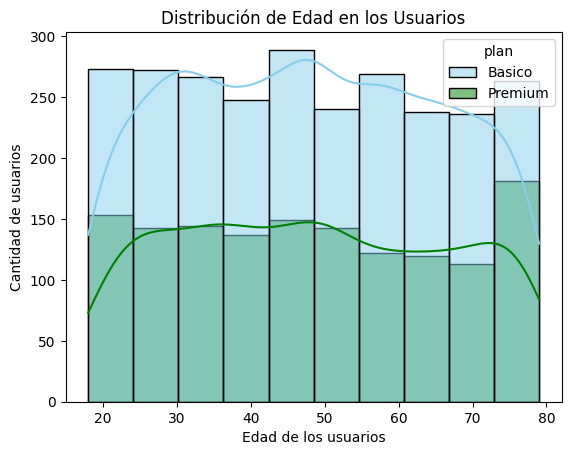

In [30]:

# Histograma para visualizar la edad (age)



sns.histplot(data=users, x='age', hue='plan', palette=['skyblue','green'], bins=10, kde=True)

plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de Edad en los Usuarios')

plt.show()





💡Insights: 
- Distribución
La distribución azul (plan:básico) es significativamente más alta en todas las edades en comparación con la verde (plan:premium). Esto indica que hay muchos más usuarios registrados en el plan básico que en el plan premium.
"Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes." o "No existe algún patrón."
Los usuarios de plan básico si tiende hacer más llamadas y enviar mensajes sobre todo los de edad de los usuarios de 30 y 45 años. 
¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)
Ambos planes siguen una distribución aproximadamente normal  o con una ligera inclinación.

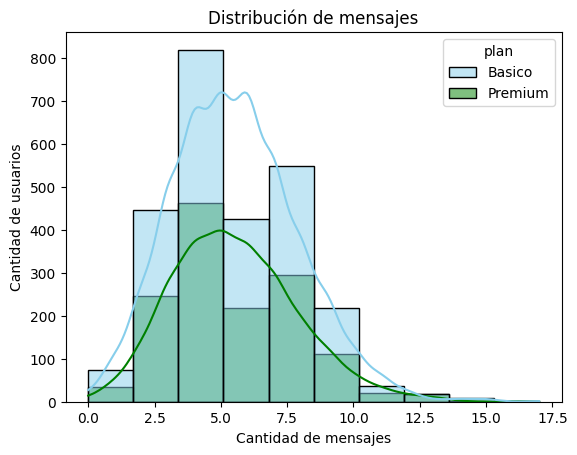

In [31]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data= user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=10, kde=True)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de mensajes')

plt.show()



💡Insights: 
En esta gráfica podemos visualizar un sesgo ala derecha, se alcanza picos mucho más altos en el eje Y (superando los 70-80 usuarios en la barra de 0 mensajes). Esto se debe a que la muestra del plan básico es numéricamente mayor que la del plan premium.Aunque el grueso de los usuarios se concentra entre 0 y 50 mensajes, la "cola" del plan básico se extiende hasta casi 200 mensajes, mientras que la del plan premium alcanza aproximadamente los 150-160 mensajes.

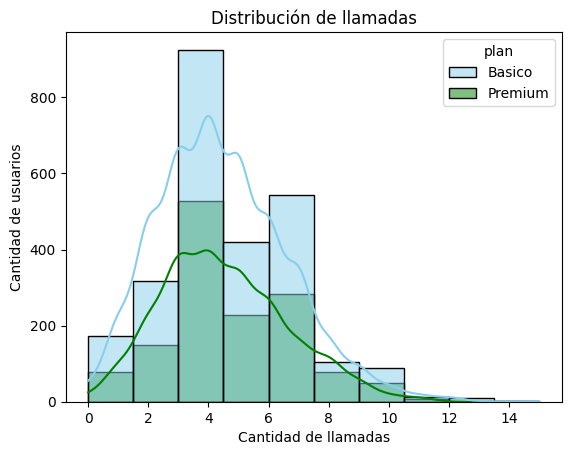

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data= user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=10, kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de llamadas')

plt.show()




💡Insights: 
- La cantidad de llamadas hace que se vea casi un distribución normal con un ligero sesgo a la derecha La mayoría de los usuarios realizan entre 50 y 70 llamadas (con el punto más alto concentrado alrededor de 60 llamadas). El Plan básico registra un volumen total más alto en el eje vertical por contar con más suscriptores, la curva de consumo por usuario es equivalente en ambos grupos. Esto confirma que contratar el plan premium no incrementa el hábito o la frecuencia de realizar llamadas telefónicas.

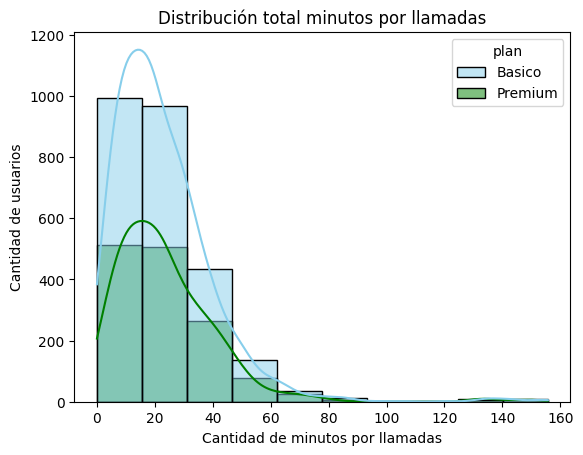

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=10, kde=True)
plt.xlabel('Cantidad de minutos por llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución total minutos por llamadas')

plt.show()


💡Insights: 

Se puede visualizar un sesgo a la derecha. La mayoría de los usuarios de ambos planes se concentra entre 0 y 50 minutos, con un pico alrededor del minuto 18-19 minutos. La cola de la distribución disminuye hacia el minuto 90  y aparecen algunos usuarios con más de 120 minutos. Ambos planes muestran un comportamiento similar , lo que sugiere que el tipo de plan básico influye en los minutos de llamadas.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

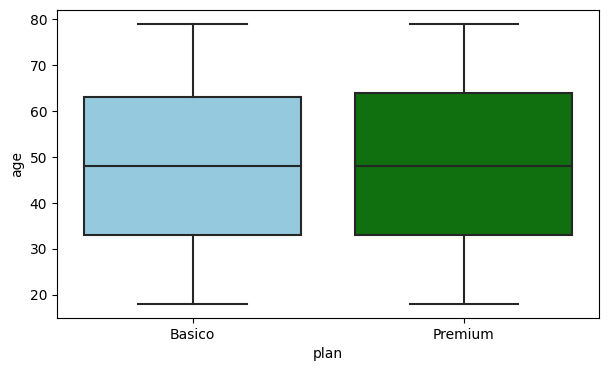

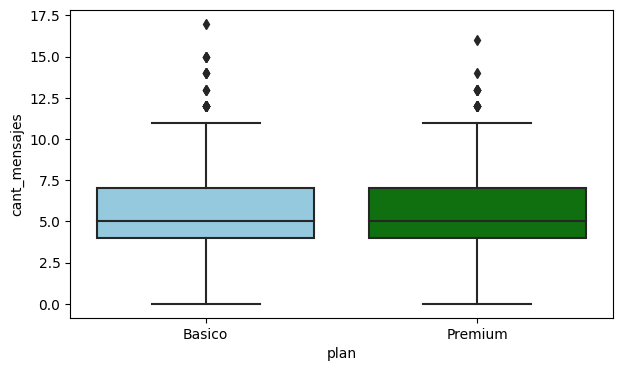

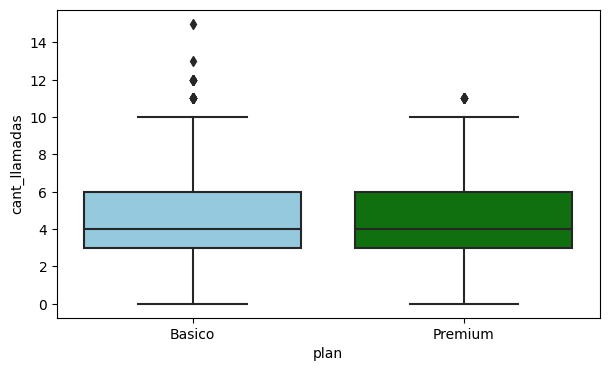

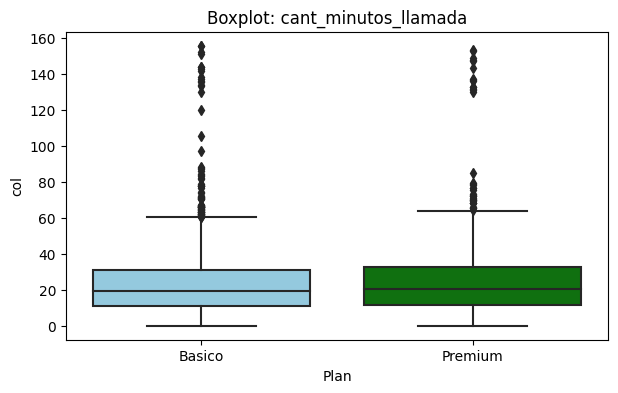

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
   plt.figure(figsize=(7, 4))
   sns.boxplot(data= user_profile, x='plan', y= col, palette=['skyblue', 'green'])

plt.xlabel('Plan')
plt.ylabel('col')
plt.title(f'Boxplot: {col}')


plt.show()

💡Insights: 
- Age: El boxplot de 'age', podemos visulizar que tanto en plan básico como el plan premium presentan la misma mediana que va de 49 llamadas, la caja de IQR son similares en ambas partes que van desde 32 al 64, no presenta outliers. 
- cant_mensajes: En el caso de cant_mensajes, la mediana del plan básico está significativamente por debajo de la del plan premium esto significa que los usuarios del plan premium envian más mensajes, el plan básico presenta un número considerable de outliers que superan los 100-150 mensajes, alcanzando picos aislados muy altos.
- cant_llamadas: Las medianas de ambos planes están muy cerca una de la otra, la altura y posición de los IQR para el plan básico y premium son prácticamente simétricas, existen pocos valores atípicos en la parte superior, mayoritariamente en el plan básico debido a que su base de datos total es mayor.
- cant_minutos_llamada: Similar al número de llamadas, el total de minutos hablados tiene una mediana muy parecida en ambos planes, los IQR del plan premium muestra una variabilidad ligeramente mayor rango, a diferencia con el plan básico que no es pronunciada.

In [35]:
# Calcular límites con el método IQR
columnas_limites =  ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(IQR)
    print(limite_inferior)
    print(limite_superior)

30.0
-12.0
108.0
3.0
-0.5
11.5
3.0
-1.5
10.5
20.295
-19.322500000000005
61.8575


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? si se debe de mantener los outliers, el envío de SMS varía drásticamente según el perfil del usuario. Mientras la mayoría casi no envía mensajes, existe un grupo reducido pero legítimo (por ejemplo, personas mayores o usuarios de autenticación SMS) que registra consumos muy altos.
- cant_llamadas: mantener o no outliers, porqué? si se debe de mantener los outliers, si se debe de mantener los outliers, la cantidad de llamadas suele seguir una distribución aproximadamente normal.
- cant_minutos_llamada: mantener o no outliers, porqué? si se debe de mantener los outliers, los minutos consumidos impactan directamente los límites de los planes (límites de consumo y cobros adicionales).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:

# Crear columna grupo_uso
#Definir lista de condiciones
condiciones = [
    (user_profile ['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
    (user_profile ['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
#Definir lista de etiquetas/segmentos para condición
segmentos=['Bajo uso','Uso medio']
#Aplicar con np.select(default es la etiqueta 'else')
user_profile ['grupo_uso'] = np.select(condiciones, segmentos, default='Alto uso')




In [38]:
# verificar cambio
user_profile ['grupo_uso'].head()

0    Uso medio
1     Alto uso
2    Uso medio
3     Alto uso
4     Bajo uso
Name: grupo_uso, dtype: object

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
#Definir lista de condiciones
condiciones = [
    (user_profile ['age'] < 30),  
    (user_profile ['age'] < 60)
]
#Definir lista de etiquetas/segmentos para condición
segmentos=['Joven','Adulto']
#Aplicar con np.select(default es la etiqueta 'else')
user_profile ['grupo_edad'] = np.select(condiciones, segmentos, default='Adulto Mayor')



In [40]:
# verificar cambios
user_profile ['grupo_edad'].head()

0          Adulto
1          Adulto
2          Adulto
3    Adulto Mayor
4    Adulto Mayor
Name: grupo_edad, dtype: object

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

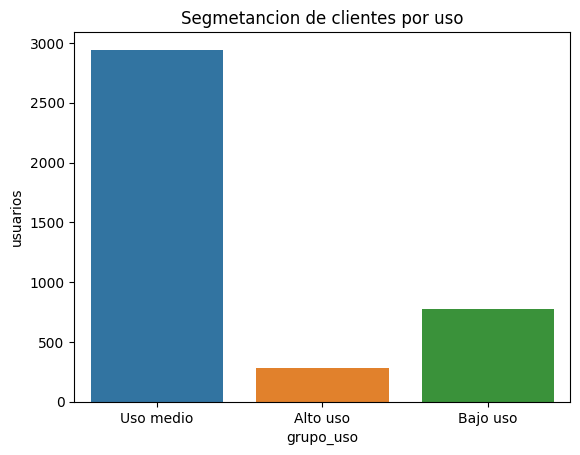

In [41]:
# Visualización de los segmentos por uso

sns.countplot(x='grupo_uso', data= user_profile)
plt.xlabel('grupo_uso')
plt.ylabel('usuarios')
plt.title('Segmetancion de clientes por uso')
plt.show()


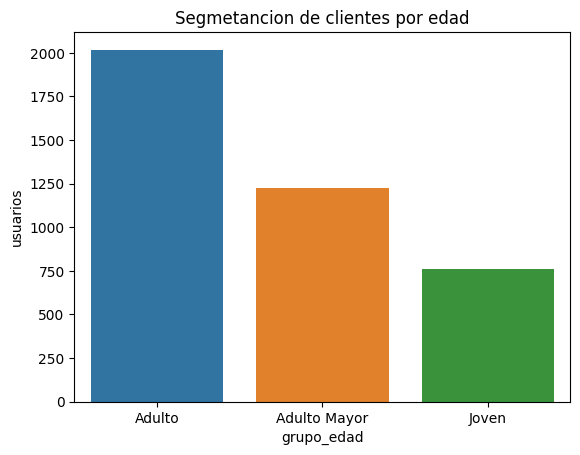

In [42]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data= user_profile)
plt.xlabel('grupo_edad')
plt.ylabel('usuarios')
plt.title('Segmetancion de clientes por edad')
plt.show()





---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se realizó un análisis exploratorio en los datasets plans, users y usage para evaluar la estructura de los datos y detectar valores nulos.

plans: No requirió verificación extensa debido a que solo contiene 2 registros.
users: Se detectaron valores faltantes en las columnas city (11.7%) y churn_date (88.3%).
usage: Presenta valores nulos en date (0.12%), duration (55.19%) y length (44.74%).

Al evaluar las variables numéricas mediante un resumen estadístico, se identificó una anomalía en la columna age, con un valor mínimo de -999. Este valor funciona como un indicador de dato ausente/nulo y debe ser filtrado o imputado, ya que distorsiona el cálculo de la media y la desviación estándar.
Por otro lado, las columnas categóricas e identificadores (id y user_id) muestran registros continuos dentro de un rango de 1 a 40,000. Finalmente, las variables duration y length presentan un sesgo debido a registros incompletos: duration cuenta con 17,924 registros (faltando 22,076) y length cuenta con 22,104 (faltando 17,896). Esta falta de completitud invalida la precisión de sus métricas descriptivas.

🔍 **Segmentos por Edad**
Con base en las visualizaciones, el segmento de "Adultos" (30 a 59 años) representa el mercado predominante con un nivel de consumo intermedio, tanto en los planes Básicos como Premium. Este comportamiento se atribuye a una mayor estabilidad económica en este grupo demográfico.Por su parte, el segmento de "Adultos Mayores" (60 años en adelante) registra un uso e intensidad de consumo elevado por usuario; sin embargo, representa un volumen menor dentro de la base total, lo cual podría explicarse por las barreras de adoptabilidad tecnológica para este grupo de edad.Finalmente, el segmento de "Jóvenes" (menores de 30 años) presenta un volumen de usuarios superior al de Adultos Mayores debido a su alta adopción digital, pero registra el nivel de consumo más bajo entre los tres segmentos, condicionado principalmente por un menor poder adquisitivo.

📊 **Segmentos por Nivel de Uso**
El Segmento Prioritario (Mayor Valor Actual): Adultos (30–59 años)
Mayor Volumen  y más  estabilidad,  al ser el grupo con más usuarios y mayor estabilidad financiera, representan la fuente principal y constante de ingresos de la compañía y  tienen la capacidad de mantener contratos a largo plazo debido a su solvencia.
El Segmento de Oportunidad a Futuro: Jóvenes (< 30 años)
Adoptabilidad Tecnológica: Dominan el uso de la telefonía y demandarán servicios de mayor valor agregado. Aunque hoy tienen menor poder adquisitivo, conforme ingresen al mercado laboral formal incrementarán su gasto. Captarlos temprano genera lealtad a largo plazo.
El Segmento Nicho Adultos Mayores (≥ 60 años)
Representa el Mayor Valor por Usuario: Tienen un consumo intensivo, pero su baja adopción tecnológica y menor volumen total limitan su capacidad de escalar el negocio.

➡️ Esto sugiere que ...
Para detectar valores extremos en las variables clave de uso y clientes: 

Se realizó un analisis en  la columna de cant_mansajes los outliers se deben de mantener ya que el  envío de SMS varía drásticamente según el perfil del usuario. Mientras la mayoría casi no envía mensajes, existe un grupo reducido pero legítimo (por ejemplo, personas mayores o usuarios de autenticación SMS) que registra consumos muy altos.

Para la columna cant_llamadas  los valores en los extremos superiores representan hábitos reales de uso intensivo y no fallas en la captura de datos. Mantenerlos ayuda a entender la capacidad de red necesaria.

cant_minutos_llamada, los minutos consumidos impactan directamente los límites de los planes (límites de consumo y cobros adicionales), haciendo que estos presenten patrones de uso extremo. 

💡 **Recomendaciones**
Proteger y monetizar el segmento de Adultos, ya que financia la operación actual.

Implementar planes accesibles y paquetes de datos para Jóvenes, asegurando su retención para convertirlos en el segmento "Adultos" del mañana.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`